Loading dataset

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [39]:
file_path = "/Users/ahmadabotrab/Desktop/patient_survival_prediction/data/patients_data.csv"

In [40]:
df = pd.read_csv(file_path)

In [41]:
df.head()

,encounter_id,patient_id,hospital_id,age,bmi,elective_surgery,ethnicity,gender,height,icu_admit_source,...,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,apache_3j_bodysystem,apache_2_bodysystem,hospital_death
0,66154,25312,118,68.0,22.73,0,Caucasian,M,180.3,Floor,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Sepsis,Cardiovascular,0
1,114252,59342,81,77.0,27.42,0,Caucasian,F,160.0,Floor,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Respiratory,Respiratory,0
2,119783,50777,118,25.0,31.95,0,Caucasian,F,172.7,Accident & Emergency,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Metabolic,Metabolic,0
3,79267,46918,118,81.0,22.64,1,Caucasian,F,165.1,Operating Room / Recovery,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Cardiovascular,Cardiovascular,0
4,92056,34377,33,19.0,NaN,0,Caucasian,M,188.0,Accident & Emergency,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Trauma,Trauma,0


In [42]:
# Target distribution
print(df['hospital_death'].value_counts())
print(df['hospital_death'].value_counts(normalize=True).round(3))

# Missing values overview
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

hospital_death
0    83798
1     7915
Name: count, dtype: int64
hospital_death
0    0.914
1    0.086
Name: proportion, dtype: float64


d1_potassium_min            9585
d1_potassium_max            9585
h1_mbp_noninvasive_min      9084
h1_mbp_noninvasive_max      9084
apache_4a_icu_death_prob    7947
                            ... 
d1_sysbp_min                 159
d1_heartrate_max             145
d1_heartrate_min             145
icu_admit_source             112
gender                        25
Length: 74, dtype: int64

In [43]:
df.columns.tolist()

['encounter_id',
 'patient_id',
 'hospital_id',
 'age',
 'bmi',
 'elective_surgery',
 'ethnicity',
 'gender',
 'height',
 'icu_admit_source',
 'icu_id',
 'icu_stay_type',
 'icu_type',
 'pre_icu_los_days',
 'weight',
 'apache_2_diagnosis',
 'apache_3j_diagnosis',
 'apache_post_operative',
 'arf_apache',
 'gcs_eyes_apache',
 'gcs_motor_apache',
 'gcs_unable_apache',
 'gcs_verbal_apache',
 'heart_rate_apache',
 'intubated_apache',
 'map_apache',
 'resprate_apache',
 'temp_apache',
 'ventilated_apache',
 'd1_diasbp_max',
 'd1_diasbp_min',
 'd1_diasbp_noninvasive_max',
 'd1_diasbp_noninvasive_min',
 'd1_heartrate_max',
 'd1_heartrate_min',
 'd1_mbp_max',
 'd1_mbp_min',
 'd1_mbp_noninvasive_max',
 'd1_mbp_noninvasive_min',
 'd1_resprate_max',
 'd1_resprate_min',
 'd1_spo2_max',
 'd1_spo2_min',
 'd1_sysbp_max',
 'd1_sysbp_min',
 'd1_sysbp_noninvasive_max',
 'd1_sysbp_noninvasive_min',
 'd1_temp_max',
 'd1_temp_min',
 'h1_diasbp_max',
 'h1_diasbp_min',
 'h1_diasbp_noninvasive_max',
 'h1_diasbp

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91713 entries, 0 to 91712
Data columns (total 84 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   encounter_id                   91713 non-null  int64  
 1   patient_id                     91713 non-null  int64  
 2   hospital_id                    91713 non-null  int64  
 3   age                            87485 non-null  float64
 4   bmi                            88284 non-null  float64
 5   elective_surgery               91713 non-null  int64  
 6   ethnicity                      90318 non-null  object 
 7   gender                         91688 non-null  object 
 8   height                         90379 non-null  float64
 9   icu_admit_source               91601 non-null  object 
 10  icu_id                         91713 non-null  int64  
 11  icu_stay_type                  91713 non-null  object 
 12  icu_type                       91713 non-null 

In [45]:
df.describe()

,encounter_id,patient_id,hospital_id,age,bmi,elective_surgery,height,icu_id,pre_icu_los_days,weight,...,apache_4a_icu_death_prob,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,hospital_death
count,91713.000000,91713.000000,91713.000000,87485.000000,88284.000000,91713.000000,90379.000000,91713.000000,91713.000000,88993.000000,...,83766.000000,90998.000000,90998.000000,90998.000000,90998.000000,90998.000000,90998.000000,90998.000000,90998.000000,91713.000000
mean,65606.079280,65537.131464,105.669262,62.309516,29.185818,0.183736,169.641588,508.357692,0.835766,84.028340,...,0.043955,0.000857,0.015693,0.225192,0.012989,0.026165,0.007066,0.004132,0.020638,0.086302
std,37795.088538,37811.252183,62.854406,16.775119,8.275142,0.387271,10.795378,228.989661,2.487756,25.011497,...,0.217341,0.029265,0.124284,0.417711,0.113229,0.159628,0.083763,0.064148,0.142169,0.280811
min,1.000000,1.000000,2.000000,16.000000,14.844926,0.000000,137.200000,82.000000,-24.947222,38.600000,...,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,32852.000000,32830.000000,47.000000,52.000000,23.641975,0.000000,162.500000,369.000000,0.035417,66.800000,...,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,65665.000000,65413.000000,109.000000,65.000000,27.654655,0.000000,170.100000,504.000000,0.138889,80.300000,...,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,98342.000000,98298.000000,161.000000,75.000000,32.930206,0.000000,177.800000,679.000000,0.409028,97.100000,...,0.060000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,131051.000000,131051.000000,204.000000,89.000000,67.814990,1.000000,195.590000,927.000000,159.090972,186.000000,...,0.970000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [46]:
df.describe(include="object")

,ethnicity,gender,icu_admit_source,icu_stay_type,icu_type,apache_3j_bodysystem,apache_2_bodysystem
count,90318,91688,91601,91713,91713,90051,90051
unique,6,2,5,3,8,11,10
top,Caucasian,M,Accident & Emergency,admit,Med-Surg ICU,Cardiovascular,Cardiovascular
freq,70684,49469,54060,86183,50586,29999,38816


In [47]:
df['hospital_death'].value_counts()

hospital_death
0    83798
1     7915
Name: count, dtype: int64

In [48]:
df['hospital_death'].value_counts(normalize=True)

hospital_death
0    0.913698
1    0.086302
Name: proportion, dtype: float64

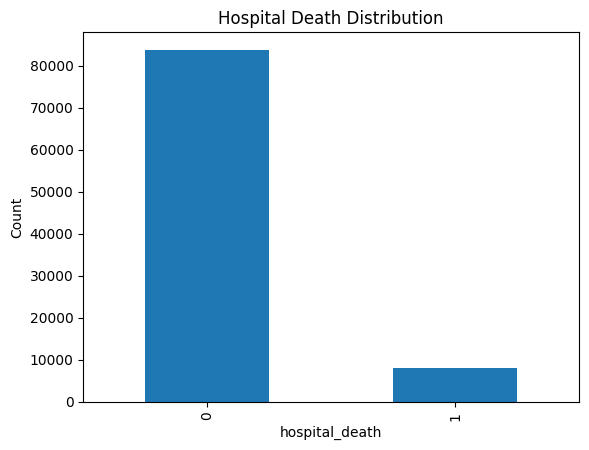

In [49]:
df["hospital_death"].value_counts().plot(kind="bar")
plt.title("Hospital Death Distribution")
plt.xlabel("hospital_death")
plt.ylabel("Count")
plt.show()

In [50]:
summary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.values,
    "missing_count": df.isnull().sum().values,
    "missing_pct": (df.isnull().mean() * 100).values,
    "n_unique": df.nunique().values
})

summary.sort_values("missing_pct", ascending=False)

,column,dtype,missing_count,missing_pct,n_unique
69,d1_potassium_max,float64,9585,10.451081,100
70,d1_potassium_min,float64,9585,10.451081,116
57,h1_mbp_noninvasive_max,float64,9084,9.904812,115
58,h1_mbp_noninvasive_min,float64,9084,9.904812,107
72,apache_4a_icu_death_prob,float64,7947,8.665075,99
...,...,...,...,...,...
11,icu_stay_type,object,0,0.000000,3
10,icu_id,int64,0,0.000000,241
5,elective_surgery,int64,0,0.000000,2
2,hospital_id,int64,0,0.000000,147


In [51]:
summary.sort_values(["missing_pct", "n_unique"], ascending=[False, True])

,column,dtype,missing_count,missing_pct,n_unique
69,d1_potassium_max,float64,9585,10.451081,100
70,d1_potassium_min,float64,9585,10.451081,116
58,h1_mbp_noninvasive_min,float64,9084,9.904812,107
57,h1_mbp_noninvasive_max,float64,9084,9.904812,115
72,apache_4a_icu_death_prob,float64,7947,8.665075,99
...,...,...,...,...,...
2,hospital_id,int64,0,0.000000,147
10,icu_id,int64,0,0.000000,241
13,pre_icu_los_days,float64,0,0.000000,9757
0,encounter_id,int64,0,0.000000,91713


Training Models and try (LogisticRegression , RandomForestClassifier , KNeighborsClassifier,DecisionTreeClassifier)

In [53]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              classification_report, confusion_matrix,
                              precision_score, recall_score)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [54]:
X = df.drop(columns=['hospital_death'])
y = df['hospital_death']

cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include='number').columns.tolist()

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Fit preprocessor once (needed for KNN and tuning outside Pipeline)
X_train_p = preprocessor.fit_transform(X_train)
X_test_p  = preprocessor.transform(X_test)

scale_pos = int((y_train == 0).sum() / (y_train == 1).sum())

results = {}
print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Class imbalance ratio (scale_pos_weight): {scale_pos}")

Train: 73370 | Test: 18343
Class imbalance ratio (scale_pos_weight): 10


## Model 1 — Logistic Regression
Simple linear baseline. No tuning needed.

=== Logistic Regression ===
              precision    recall  f1-score   support

    Survived       0.97      0.81      0.88     16760
        Died       0.27      0.76      0.40      1583

    accuracy                           0.80     18343
   macro avg       0.62      0.78      0.64     18343
weighted avg       0.91      0.80      0.84     18343



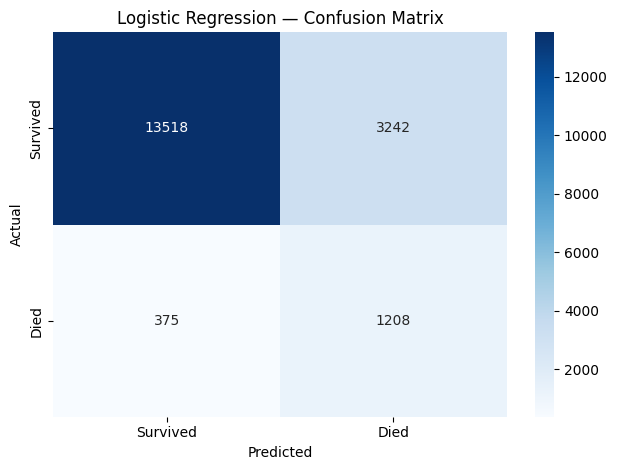

In [56]:
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_p, y_train)

pred  = lr.predict(X_test_p)
proba = lr.predict_proba(X_test_p)[:, 1]

results['Logistic Regression'] = {
    'accuracy':    accuracy_score(y_test, pred),
    'macro_f1':    f1_score(y_test, pred, average='macro'),
    'roc_auc':     roc_auc_score(y_test, proba),
    'precision_1': precision_score(y_test, pred, pos_label=1),
    'recall_1':    recall_score(y_test, pred, pos_label=1),
    'pred': pred, 'proba': proba,
    'cm':   confusion_matrix(y_test, pred),
    'best_params': 'No tuning'
}

print("=== Logistic Regression ===")
print(classification_report(y_test, pred, target_names=['Survived', 'Died']))

cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Survived','Died'], yticklabels=['Survived','Died'])
plt.title('Logistic Regression — Confusion Matrix')
plt.xlabel('Predicted') ; plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('../output/figures/cm_logistic_regression.png', dpi=150, bbox_inches='tight')
plt.show()

## Model 2 — Decision Tree
Tuned with RandomizedSearchCV (max_depth, min_samples_split, criterion).

=== Decision Tree ===
Best params: {'min_samples_split': 10, 'min_samples_leaf': 10, 'max_depth': 5, 'criterion': 'entropy'}
              precision    recall  f1-score   support

    Survived       0.97      0.81      0.88     16760
        Died       0.26      0.74      0.39      1583

    accuracy                           0.80     18343
   macro avg       0.62      0.77      0.63     18343
weighted avg       0.91      0.80      0.84     18343



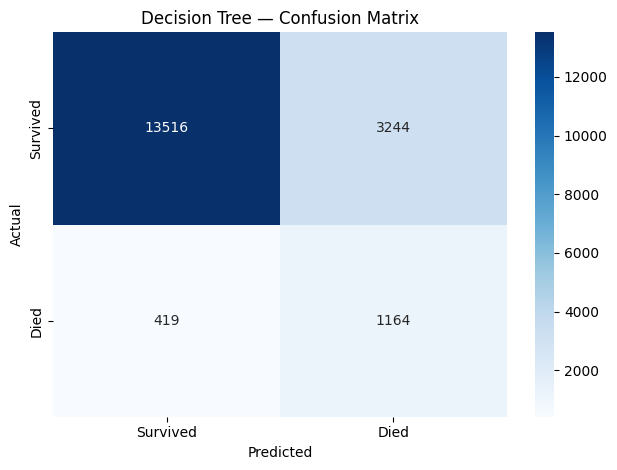

In [57]:
dt_params = {
    'max_depth':         [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf':  [1, 2, 5, 10],
    'criterion':         ['gini', 'entropy'],
}
dt_search = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    dt_params, n_iter=20, cv=3, scoring='f1_macro', n_jobs=-1, random_state=42
)
dt_search.fit(X_train_p, y_train)
best_dt = dt_search.best_estimator_

pred  = best_dt.predict(X_test_p)
proba = best_dt.predict_proba(X_test_p)[:, 1]

results['Decision Tree'] = {
    'accuracy':    accuracy_score(y_test, pred),
    'macro_f1':    f1_score(y_test, pred, average='macro'),
    'roc_auc':     roc_auc_score(y_test, proba),
    'precision_1': precision_score(y_test, pred, pos_label=1),
    'recall_1':    recall_score(y_test, pred, pos_label=1),
    'pred': pred, 'proba': proba,
    'cm':   confusion_matrix(y_test, pred),
    'best_params': dt_search.best_params_
}

print("=== Decision Tree ===")
print(f"Best params: {dt_search.best_params_}")
print(classification_report(y_test, pred, target_names=['Survived', 'Died']))

cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Survived','Died'], yticklabels=['Survived','Died'])
plt.title('Decision Tree — Confusion Matrix')
plt.xlabel('Predicted') ; plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('../output/figures/cm_decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()

## Model 3 — Random Forest
Tuned with RandomizedSearchCV (n_estimators, max_depth, min_samples_split).

=== Random Forest ===
Best params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 15}
              precision    recall  f1-score   support

    Survived       0.95      0.95      0.95     16760
        Died       0.47      0.50      0.49      1583

    accuracy                           0.91     18343
   macro avg       0.71      0.73      0.72     18343
weighted avg       0.91      0.91      0.91     18343



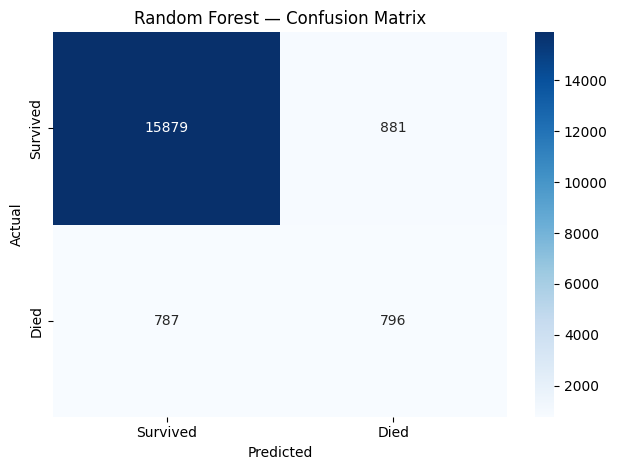

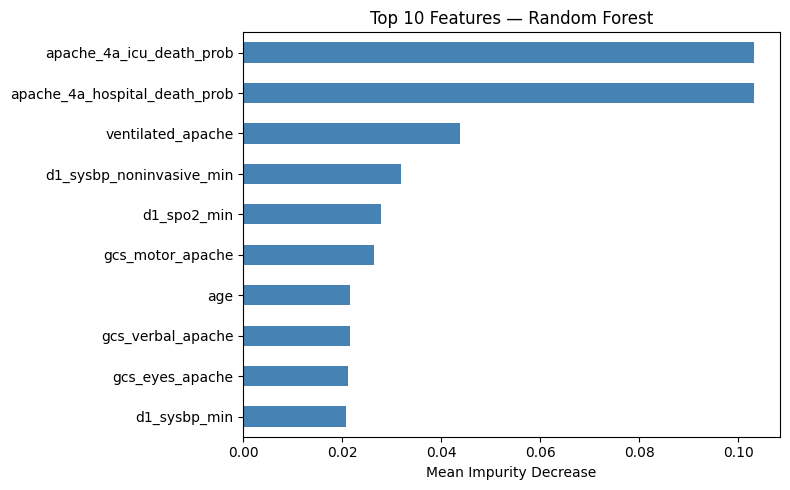

In [58]:
rf_params = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1),
    rf_params, n_iter=15, cv=3, scoring='f1_macro', n_jobs=-1, random_state=42
)
rf_search.fit(X_train_p, y_train)
best_rf = rf_search.best_estimator_

pred  = best_rf.predict(X_test_p)
proba = best_rf.predict_proba(X_test_p)[:, 1]

results['Random Forest'] = {
    'accuracy':    accuracy_score(y_test, pred),
    'macro_f1':    f1_score(y_test, pred, average='macro'),
    'roc_auc':     roc_auc_score(y_test, proba),
    'precision_1': precision_score(y_test, pred, pos_label=1),
    'recall_1':    recall_score(y_test, pred, pos_label=1),
    'pred': pred, 'proba': proba,
    'cm':   confusion_matrix(y_test, pred),
    'best_params': rf_search.best_params_
}

print("=== Random Forest ===")
print(f"Best params: {rf_search.best_params_}")
print(classification_report(y_test, pred, target_names=['Survived', 'Died']))

cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Survived','Died'], yticklabels=['Survived','Died'])
plt.title('Random Forest — Confusion Matrix')
plt.xlabel('Predicted') ; plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('../output/figures/cm_random_forest.png', dpi=150, bbox_inches='tight')
plt.show()

# Feature Importance
ohe_features = (preprocessor.named_transformers_['cat']['encoder']
                              .get_feature_names_out(cat_cols).tolist())
all_features = num_cols + ohe_features
importances  = best_rf.feature_importances_
top10 = pd.Series(importances, index=all_features).nlargest(10)

plt.figure(figsize=(8, 5))
top10.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 10 Features — Random Forest')
plt.xlabel('Mean Impurity Decrease')
plt.tight_layout()
plt.savefig('../output/figures/feature_importance_rf.png', dpi=150, bbox_inches='tight')
plt.show()

## Model 5 — K-Nearest Neighbors (KNN)
Tuned with RandomizedSearchCV (n_neighbors, weights, metric).

=== KNN ===
Best params: {'weights': 'distance', 'n_neighbors': 3, 'metric': 'manhattan'}
              precision    recall  f1-score   support

    Survived       0.93      0.99      0.96     16760
        Died       0.57      0.19      0.28      1583

    accuracy                           0.92     18343
   macro avg       0.75      0.59      0.62     18343
weighted avg       0.90      0.92      0.90     18343



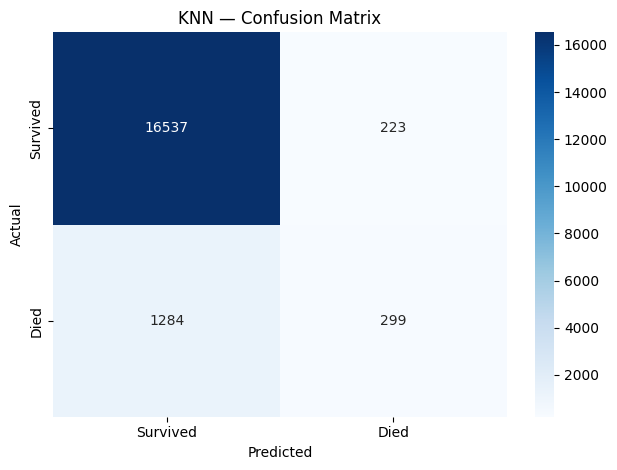

In [59]:
knn_params = {
    'n_neighbors': [3, 5, 7, 11, 15, 21],
    'weights':     ['uniform', 'distance'],
    'metric':      ['euclidean', 'manhattan'],
}
knn_search = RandomizedSearchCV(
    KNeighborsClassifier(n_jobs=-1),
    knn_params, n_iter=12, cv=3, scoring='f1_macro', n_jobs=-1, random_state=42
)
knn_search.fit(X_train_p, y_train)
best_knn = knn_search.best_estimator_

pred  = best_knn.predict(X_test_p)
proba = best_knn.predict_proba(X_test_p)[:, 1]

results['KNN'] = {
    'accuracy':    accuracy_score(y_test, pred),
    'macro_f1':    f1_score(y_test, pred, average='macro'),
    'roc_auc':     roc_auc_score(y_test, proba),
    'precision_1': precision_score(y_test, pred, pos_label=1),
    'recall_1':    recall_score(y_test, pred, pos_label=1),
    'pred': pred, 'proba': proba,
    'cm':   confusion_matrix(y_test, pred),
    'best_params': knn_search.best_params_
}

print("=== KNN ===")
print(f"Best params: {knn_search.best_params_}")
print(classification_report(y_test, pred, target_names=['Survived', 'Died']))

cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Survived','Died'], yticklabels=['Survived','Died'])
plt.title('KNN — Confusion Matrix')
plt.xlabel('Predicted') ; plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('../output/figures/cm_knn.png', dpi=150, bbox_inches='tight')
plt.show()

## Model Comparison

In [60]:
summary = pd.DataFrame({
    name: {
        'Accuracy':    r['accuracy'],
        'Macro F1':    r['macro_f1'],
        'ROC-AUC':     r['roc_auc'],
        'Precision (Died)': r['precision_1'],
        'Recall (Died)':    r['recall_1'],
    }
    for name, r in results.items()
}).T.round(4)

summary.sort_values('Macro F1', ascending=False)

,Accuracy,Macro F1,ROC-AUC,Precision (Died),Recall (Died)
Random Forest,0.9091,0.7192,0.8826,0.4747,0.5028
Logistic Regression,0.8028,0.6412,0.8761,0.2715,0.7631
Decision Tree,0.8003,0.6346,0.8565,0.2641,0.7353
KNN,0.9178,0.6203,0.6802,0.5728,0.1889


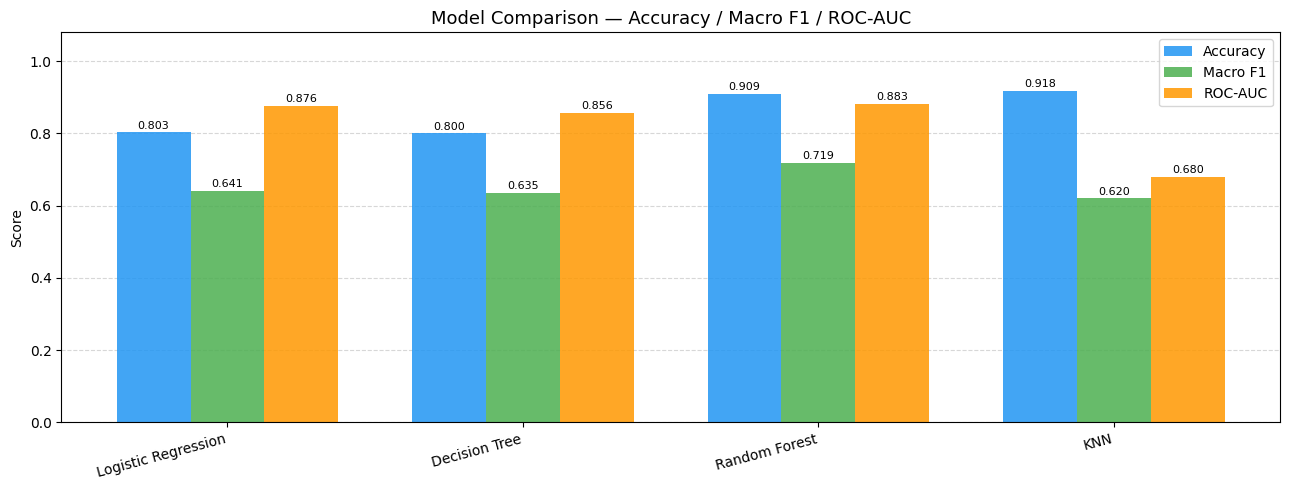

In [61]:
metrics   = ['Accuracy', 'Macro F1', 'ROC-AUC']
model_names = list(results.keys())
x = np.arange(len(model_names))
width = 0.25
colors_list = ['#2196F3', '#4CAF50', '#FF9800']

fig, ax = plt.subplots(figsize=(13, 5))

for i, (metric, color) in enumerate(zip(metrics, colors_list)):
    values = [results[m][metric.lower().replace(' ', '_')
                          .replace('-', '_')
                          .replace('macro_f1', 'macro_f1')
                          .replace('roc_auc', 'roc_auc')]
              for m in model_names]

    if metric == 'Accuracy':
        vals = [results[m]['accuracy'] for m in model_names]
    elif metric == 'Macro F1':
        vals = [results[m]['macro_f1'] for m in model_names]
    else:
        vals = [results[m]['roc_auc'] for m in model_names]

    bars = ax.bar(x + i * width, vals, width, label=metric, color=color, alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.set_ylim(0, 1.08)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Accuracy / Macro F1 / ROC-AUC', fontsize=13)
ax.legend()
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('../output/figures/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()